# Análise de Dados Climáticos – Previsão de Temperatura Aparente

Este notebook percorre todo o pipeline de Data Science para o conjunto **Weather History**:

1. Instalação de dependências  
2. Aquisição e limpeza dos dados  
3. Análise exploratória  
4. Modelagem preditiva  
5. Conclusões


In [1]:
# 1. Instalação de dependências
%pip install pandas matplotlib seaborn scikit-learn



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Aquisição e Limpeza dos Dados


In [2]:
# 2.1 Definição das funções de limpeza
import os
import pandas as pd

def load_raw(path: str = "data/weatherHistory.csv") -> pd.DataFrame:
    """
    Carrega CSV com parse de datas e retorna DataFrame.
    Converte a coluna 'Formatted Date' para datetime UTC.
    """
    df = pd.read_csv(path, parse_dates=["Formatted Date"])
    df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)
    return df

def clean(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove colunas irrelevantes, duplicatas, trata missings em 'Precip Type'
    e descarta registros sem data.
    """
    to_drop = ["Loud Cover", "Daily Summary"]
    df = df.drop(columns=[c for c in to_drop if c in df], errors="ignore")
    df = df.drop_duplicates()
    df["Precip Type"] = df["Precip Type"].fillna("none")
    df = df.dropna(subset=["Formatted Date"])
    return df

def save(df: pd.DataFrame, path: str = "data/weatherHistory_clean.csv") -> None:
    """Salva DataFrame limpo em CSV."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_csv(path, index=False)
    print(f"✅ Dados limpos gravados em {path}")

# 2.2 Execução do pipeline de limpeza
raw_df   = load_raw("data/weatherHistory.csv")
clean_df = clean(raw_df)
save(clean_df, "data/weatherHistory_clean.csv")

# 2.3 Visualizar resultado
clean_df.head()


✅ Dados limpos gravados em data/weatherHistory_clean.csv


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
0,2006-03-31 22:00:00+00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13
1,2006-03-31 23:00:00+00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94
3,2006-04-01 01:00:00+00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51


## 3. Análise Exploratória



--- Estatísticas Numéricas ---
       Temperature (C)  Apparent Temperature (C)      Humidity  \
count     96429.000000              96429.000000  96429.000000   
mean         11.929692                 10.851707      0.734902   
std           9.550492                 10.695743      0.195466   
min         -21.822222                -27.716667      0.000000   
25%           4.683333                  2.311111      0.600000   
50%          12.000000                 12.000000      0.780000   
75%          18.838889                 18.838889      0.890000   
max          39.905556                 39.344444      1.000000   

       Wind Speed (km/h)  Wind Bearing (degrees)  Visibility (km)  \
count       96429.000000            96429.000000     96429.000000   
mean           10.812460              187.497506        10.347225   
std             6.913345              107.376423         4.192548   
min             0.000000                0.000000         0.000000   
25%             5.828200    

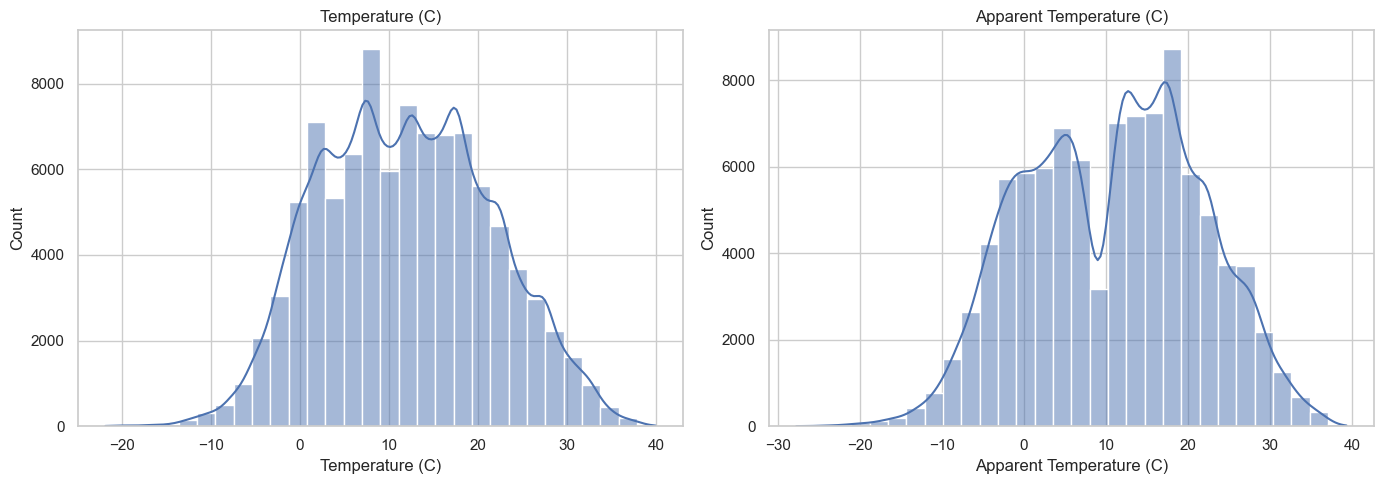

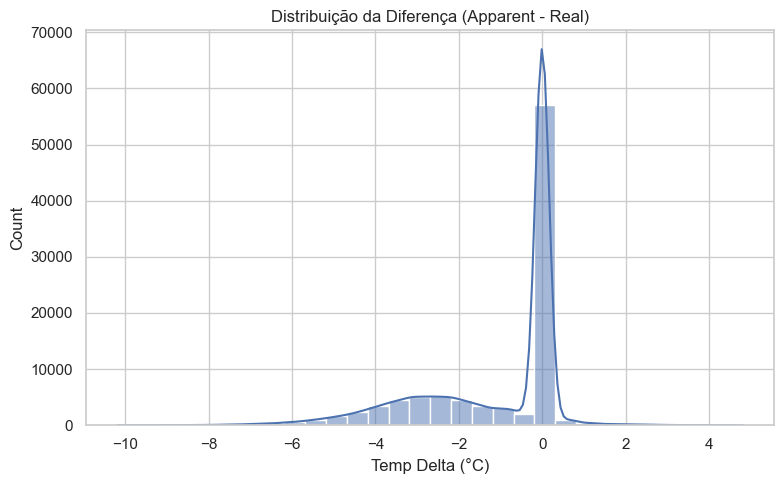

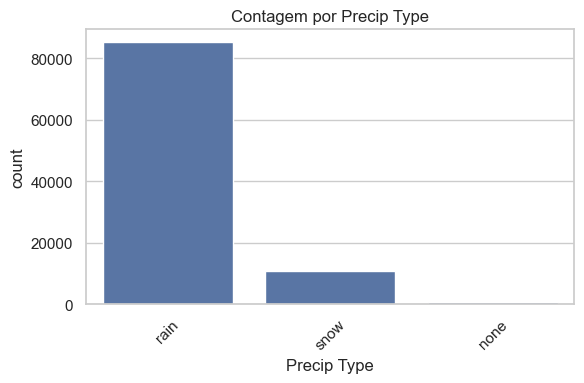

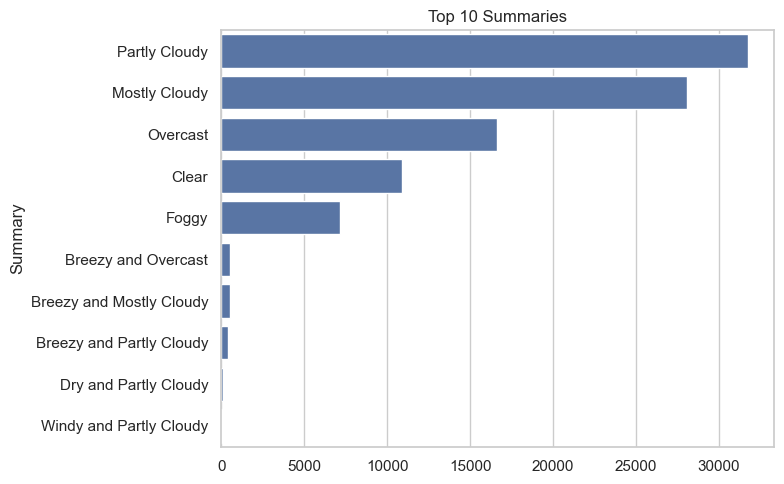

/var/folders/5_/6mrcqx916wj503857_96j_g80000gn/T/ipykernel_39513/255484000.py:51: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_month = df.set_index("Formatted Date")["Apparent Temperature (C)"].resample("M").mean()


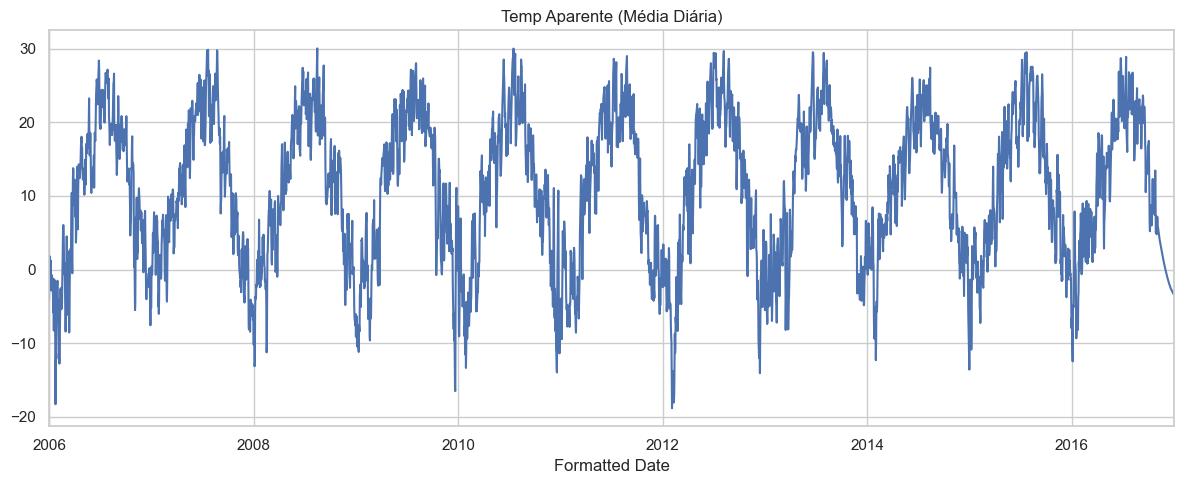

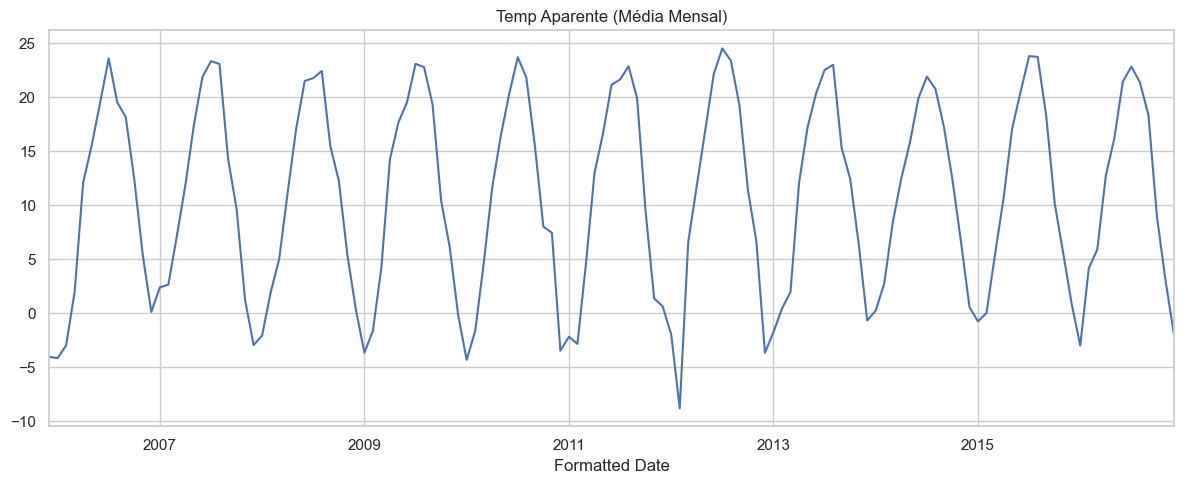

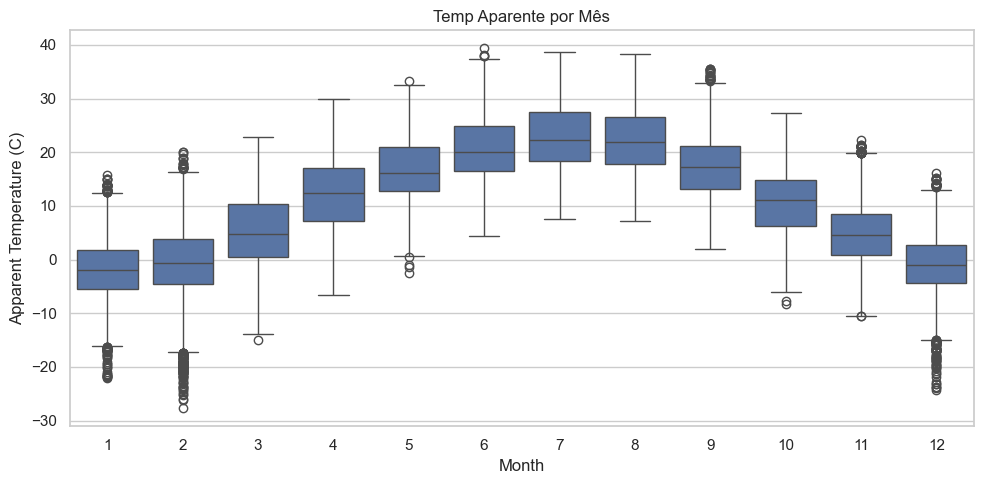

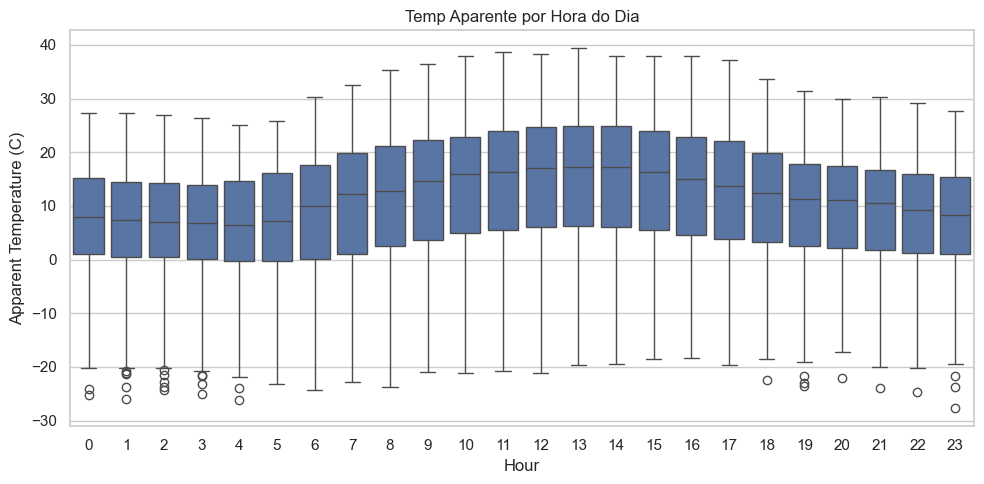

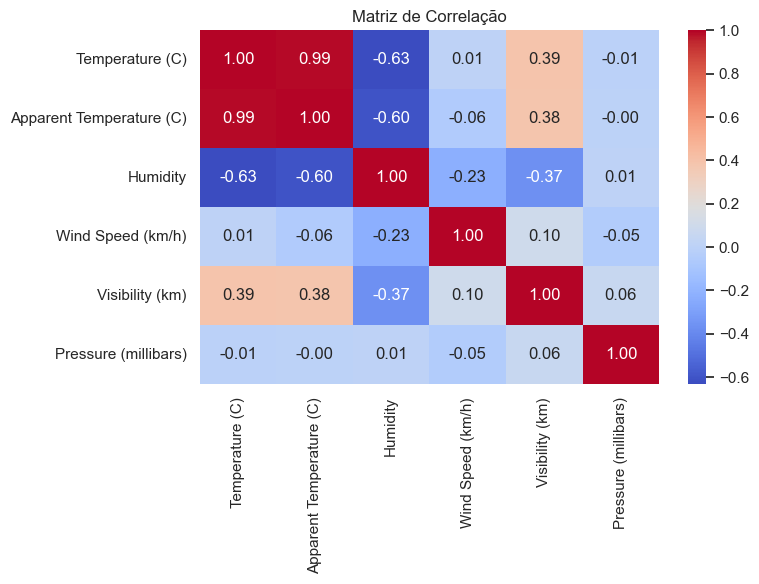

In [3]:
# 3.1 Import e setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

# 3.2 Carregar dados limpos
df = pd.read_csv("data/weatherHistory_clean.csv", parse_dates=["Formatted Date"])

# 3.3 Estatísticas descritivas
print("\n--- Estatísticas Numéricas ---")
print(df.describe())
print("\n--- Estatísticas Categóricas ---")
print(df.describe(include=["object"]))

# 3.4 Distribuições de temperatura real vs aparente
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df["Temperature (C)"],            bins=30, kde=True, ax=ax1).set(title="Temperature (C)")
sns.histplot(df["Apparent Temperature (C)"], bins=30, kde=True, ax=ax2).set(title="Apparent Temperature (C)")
plt.tight_layout()
plt.show()

# 3.5 Diferença (Apparent - Real)
df["Temp Delta"] = df["Apparent Temperature (C)"] - df["Temperature (C)"]
plt.figure(figsize=(8,5))
sns.histplot(df["Temp Delta"], bins=30, kde=True)
plt.title("Distribuição da Diferença (Apparent - Real)")
plt.xlabel("Temp Delta (°C)")
plt.tight_layout()
plt.show()

# 3.6 Contagens categóricas
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Precip Type", order=df["Precip Type"].value_counts().index)
plt.title("Contagem por Precip Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_summ = df["Summary"].value_counts().nlargest(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_summ.values, y=top_summ.index)
plt.title("Top 10 Summaries")
plt.tight_layout()
plt.show()

# 3.7 Séries temporais diária e mensal
ts_daily = df.set_index("Formatted Date")["Apparent Temperature (C)"].resample("D").mean()
ts_month = df.set_index("Formatted Date")["Apparent Temperature (C)"].resample("M").mean()

plt.figure(figsize=(12,5))
ts_daily.plot()
plt.title("Temp Aparente (Média Diária)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
ts_month.plot()
plt.title("Temp Aparente (Média Mensal)")
plt.tight_layout()
plt.show()

# 3.8 Boxplots sazonais
df["Month"] = df["Formatted Date"].dt.month
df["Hour"]  = df["Formatted Date"].dt.hour

plt.figure(figsize=(10,5))
sns.boxplot(x="Month", y="Apparent Temperature (C)", data=df)
plt.title("Temp Aparente por Mês")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x="Hour", y="Apparent Temperature (C)", data=df)
plt.title("Temp Aparente por Hora do Dia")
plt.tight_layout()
plt.show()

# 3.9 Matriz de correlação
num_cols = ["Temperature (C)", "Apparent Temperature (C)", "Humidity",
            "Wind Speed (km/h)", "Visibility (km)", "Pressure (millibars)"]
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()


## 4. Modelagem Preditiva

### Por que usar Machine Learning para previsão de temperatura aparente?

Modelos de machine learning permitem prever a temperatura aparente a partir de diversas variáveis meteorológicas, capturando relações complexas entre elas. Isso é útil porque:

- Permite estimar a sensação térmica em situações futuras, mesmo sem medições diretas.
- Ajuda a entender quais fatores mais influenciam a sensação térmica.
- Gera previsões mais precisas do que métodos estatísticos simples, pois aprende padrões a partir dos dados históricos.

No contexto deste notebook, a modelagem preditiva é usada para comparar diferentes algoritmos e avaliar qual deles melhor estima a temperatura aparente com base nas demais variáveis do clima.

In [4]:
# 4.1 Import e definições
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 4.2 Carregar dados
df = pd.read_csv("data/weatherHistory_clean.csv", parse_dates=["Formatted Date"])

# 4.3 Preparar features e target
numeric_feats = ["Temperature (C)", "Humidity", "Wind Speed (km/h)",
                 "Visibility (km)", "Pressure (millibars)"]
cat_feats     = ["Summary", "Precip Type"]

df = df.dropna(subset=numeric_feats + ["Apparent Temperature (C)"])
X_num = df[numeric_feats]
X_cat = pd.get_dummies(df[cat_feats], drop_first=True)
X     = pd.concat([X_num, X_cat], axis=1)
y     = df["Apparent Temperature (C)"]

# 4.4 Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4.5 Avaliar Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)
print(f"LinearRegression -> RMSE: {mse_lr**0.5:.2f}, R²: {r2_lr:.4f}")

# 4.6 Avaliar Random Forest (leve)
rf = RandomForestRegressor(n_estimators=20, max_depth=10, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)
print(f"RandomForestRegressor -> RMSE: {mse_rf**0.5:.2f}, R²: {r2_rf:.4f}")


LinearRegression -> RMSE: 1.07, R²: 0.9901
RandomForestRegressor -> RMSE: 0.11, R²: 0.9999


## 5. Conclusões

- O pipeline de análise permitiu explorar e compreender o comportamento das variáveis meteorológicas do dataset Weather History.
- A limpeza dos dados removeu inconsistências e garantiu a qualidade para a modelagem.
- A análise exploratória revelou padrões sazonais, correlações e a importância de variáveis como temperatura real, umidade e vento na sensação térmica.
- Na modelagem preditiva, o Random Forest apresentou desempenho superior à Regressão Linear, indicando que relações não-lineares são relevantes para estimar a temperatura aparente.
- O uso de machine learning mostrou-se eficaz para prever a sensação térmica a partir de múltiplos fatores climáticos.